# Unveiling the Android App Market: Google Play Store Analysis

### Oasis Infobyte Data Analytics Internship
**Level 2 — Task 4**

This project focuses on analyzing Google Play Store application data to uncover insights into app categories, ratings, installs, pricing, size, user reviews, and sentiment.

## Task Objective

As part of the **Oasis Infobyte Data Analytics Internship**, this task aims to analyze the Android app market using Google Play Store data.

The analysis focuses on understanding app characteristics, identifying popular and saturated categories, examining ratings and installations, comparing free and paid applications, estimating potential revenue, and analyzing user review sentiment.

The project also includes interactive visualization and data-driven recommendations for developers planning to launch an app.

## 1. Import Libraries

The required Python libraries are imported for data manipulation, exploratory data analysis, visualization, sentiment analysis, and interactive visualization.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
import plotly.express as px

%matplotlib inline

### Libraries Used

- **Pandas** – Data manipulation and analysis
- **NumPy** – Numerical operations
- **Matplotlib** – Data visualization
- **Seaborn** – Statistical visualization
- **TextBlob** – Sentiment analysis of user reviews
- **Plotly** – Interactive visualizations

## 2. Load the Datasets

Two datasets are used for this analysis:

- **Google Play Store Apps Dataset** – contains information about applications, including category, rating, reviews, size, installs, type, price, content rating, genres, and update details.
- **Google Play Store User Reviews Dataset** – contains user reviews along with sentiment-related information.

Both datasets are loaded separately to support app-market analysis and user-review sentiment analysis.

In [ ]:
# Load Google Play Store Apps dataset
apps = pd.read_csv('/content/googleplaystore.csv')

# Load Google Play Store User Reviews dataset
reviews = pd.read_csv('/content/googleplaystore_user_reviews.csv')

print("Apps Dataset Shape:", apps.shape)
print("User Reviews Dataset Shape:", reviews.shape)

Apps Dataset Shape: (10841, 13)
User Reviews Dataset Shape: (64295, 5)


In [ ]:
print("Apps Dataset:")
display(apps.head())

print("\nUser Reviews Dataset:")
display(reviews.head())

Apps Dataset:


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



User Reviews Dataset:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


### Observation

- The Apps dataset contains **10,841 records and 13 columns** describing Google Play Store applications.
- The User Reviews dataset contains **64,295 records and 5 columns** containing app reviews and sentiment-related information.
- The two datasets provide the required information for analyzing app categories, ratings, installs, pricing, and user sentiment.


## 3. Dataset Information

The structure and data types of both datasets are examined to identify missing values, incorrect data types, and other data-quality issues before performing data cleaning.

In [ ]:
print("Apps Dataset Information:")
apps.info()

print("\n" + "="*60 + "\n")

print("User Reviews Dataset Information:")
reviews.info()

Apps Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


User Reviews Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 col

## 4. Missing Value Analysis

Before performing data cleaning and analysis, the number of missing values in each column is examined for both datasets. This helps determine which columns require appropriate treatment.

In [ ]:
print("Missing Values in Apps Dataset:")
print(apps.isnull().sum())

print("\n" + "="*60 + "\n")

print("Missing Values in User Reviews Dataset:")
print(reviews.isnull().sum())

Missing Values in Apps Dataset:
App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64


Missing Values in User Reviews Dataset:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


## 5. Handling Missing Values

Missing values are handled using appropriate methods based on the nature of each column.

- Missing ratings are replaced with the median rating to preserve the available app records.
- Rows with missing categorical information are removed because the number of missing records is very small.
- User review records without an actual translated review are removed because they cannot be used for sentiment analysis.

In [ ]:
# Handle missing values in Apps dataset

# Fill missing ratings with the median rating
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].median())

# Remove rows with missing categorical information
apps.dropna(subset=['Type', 'Content Rating', 'Current Ver', 'Android Ver'], inplace=True)


# Handle missing values in User Reviews dataset

# Remove reviews where the actual review text is missing
reviews.dropna(subset=['Translated_Review'], inplace=True)


print("Apps Dataset Shape after handling missing values:", apps.shape)
print("User Reviews Dataset Shape after handling missing values:", reviews.shape)

Apps Dataset Shape after handling missing values: (10829, 13)
User Reviews Dataset Shape after handling missing values: (37427, 5)


### Observation

- Missing values were successfully handled in both datasets.
- The Apps dataset now contains **10,829 records and 13 columns**.
- The User Reviews dataset now contains **37,427 records and 5 columns**.
- Removing reviews without review text ensures that the remaining records can be meaningfully used for sentiment analysis.

## 6. Duplicate Value Analysis

Duplicate records are identified in both datasets to ensure that repeated entries do not affect the accuracy of the analysis.

In [ ]:
print("Duplicate Rows in Apps Dataset:", apps.duplicated().sum())
print("Duplicate Rows in User Reviews Dataset:", reviews.duplicated().sum())

Duplicate Rows in Apps Dataset: 483
Duplicate Rows in User Reviews Dataset: 7735


### Observation

- The Apps dataset contains **483 duplicate records**.
- The User Reviews dataset contains **7,735 duplicate records**.
- Duplicate records can cause repeated information to influence the analysis, so they will be removed before further processing.

## 7. Removing Duplicate Records

Duplicate records are removed from both datasets to ensure that each record contributes appropriately to the analysis.

In [ ]:
# Remove duplicate records
apps = apps.drop_duplicates()
reviews = reviews.drop_duplicates()

print("Apps Dataset Shape after removing duplicates:", apps.shape)
print("User Reviews Dataset Shape after removing duplicates:", reviews.shape)

Apps Dataset Shape after removing duplicates: (10346, 13)
User Reviews Dataset Shape after removing duplicates: (29692, 5)


### Observation

- Duplicate records were successfully removed from both datasets.
- The Apps dataset now contains **10,346 unique records**.
- The User Reviews dataset now contains **29,692 unique records**.
- Removing duplicates helps prevent repeated records from affecting the analysis and improves the reliability of the results.

## 8. Data Type Conversion

Several columns in the Apps dataset are stored as object data types even though they represent numerical values. These columns are cleaned and converted into appropriate numerical formats for analysis.

- `Reviews` is converted to numeric.
- `Size` is converted into megabytes (MB).
- `Installs` is converted into numeric values by removing symbols such as `+` and `,`.
- `Price` is converted into numeric values by removing the `$` symbol.

In [ ]:
# Convert Reviews to numeric
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

# Convert Installs to numeric
apps['Installs'] = (
    apps['Installs']
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
    .astype(float)
)

# Convert Price to numeric
apps['Price'] = (
    apps['Price']
    .str.replace('$', '', regex=False)
    .astype(float)
)

# Convert Size to MB
def convert_size(size):
    if isinstance(size, str):
        if size.endswith('M'):
            return float(size.replace('M', ''))
        elif size.endswith('k'):
            return float(size.replace('k', '')) / 1024
        elif size == 'Varies with device':
            return np.nan
    return np.nan

apps['Size'] = apps['Size'].apply(convert_size)

print(apps[['Reviews', 'Size', 'Installs', 'Price']].dtypes)

Reviews       int64
Size        float64
Installs    float64
Price       float64
dtype: object


### Observation

- The `Reviews` column was successfully converted to an integer data type.
- The `Size`, `Installs`, and `Price` columns were successfully converted to numerical data types.
- These conversions make the columns suitable for numerical analysis and visualization.

## 9. Rechecking Missing Values

After converting columns to appropriate numerical data types, missing values are checked again to identify any values introduced during the conversion process.

In [ ]:
print("Missing Values in Apps Dataset After Data Type Conversion:")
print(apps.isnull().sum())

Missing Values in Apps Dataset After Data Type Conversion:
App                  0
Category             0
Rating               0
Reviews              0
Size              1525
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          0
Android Ver          0
dtype: int64


### Observation

- After data type conversion, **1,525 missing values** were identified in the `Size` column.
- These missing values correspond to apps whose size was originally listed as **"Varies with device"**.
- The remaining columns contain no missing values.
- The missing `Size` values will be excluded only from analyses that specifically require app size.

## 10. Final Data Quality Check

A final missing-value check is performed on the User Reviews dataset before beginning sentiment analysis.

In [ ]:
print("Missing Values in User Reviews Dataset:")
print(reviews.isnull().sum())

Missing Values in User Reviews Dataset:
App                       0
Translated_Review         0
Sentiment                 0
Sentiment_Polarity        0
Sentiment_Subjectivity    0
dtype: int64


### Observation

- No missing values remain in the User Reviews dataset.
- All review records now contain valid app names, review text, sentiment labels, polarity scores, and subjectivity scores.
- The User Reviews dataset is ready for sentiment analysis.

## 11. Cleaned Dataset Summary

After handling missing values, removing duplicate records, and correcting data types, the datasets are ready for exploratory data analysis and sentiment analysis.

In [ ]:
print("Final Apps Dataset Shape:", apps.shape)
print("Final User Reviews Dataset Shape:", reviews.shape)

print("\nApps Dataset Columns:")
print(apps.columns.tolist())

print("\nUser Reviews Dataset Columns:")
print(reviews.columns.tolist())

Final Apps Dataset Shape: (10346, 13)
Final User Reviews Dataset Shape: (29692, 5)

Apps Dataset Columns:
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

User Reviews Dataset Columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


### Observation

- After data cleaning and preprocessing, the Apps dataset contains **10,346 unique records and 13 columns**.
- The User Reviews dataset contains **29,692 unique records and 5 columns**.
- Missing values and duplicate records have been handled successfully.
- Important numerical columns in the Apps dataset have been converted to appropriate data types.
- Both datasets are now ready for exploratory data analysis.

## 12. App Distribution by Category

The distribution of applications across different categories is analyzed to understand which categories have the highest and lowest number of apps. This helps identify highly saturated areas of the Google Play Store.

In [ ]:
category_counts = apps['Category'].value_counts()

print("Number of App Categories:", category_counts.shape[0])
display(category_counts)

Number of App Categories: 33


,count
Category,
FAMILY,1939
GAME,1121
TOOLS,841
BUSINESS,427
MEDICAL,408
PRODUCTIVITY,407
PERSONALIZATION,386
LIFESTYLE,373
COMMUNICATION,366


### Observation

- The Google Play Store dataset contains **33 app categories**.
- **FAMILY** has the highest number of applications with **1,939 apps**, followed by **GAME** with **1,121** and **TOOLS** with **841**.
- Categories such as **BEAUTY, COMICS, PARENTING, and EVENTS** contain comparatively fewer applications.
- The high number of applications in categories such as FAMILY, GAME, and TOOLS indicates greater market saturation and competition in these categories.

## 13. Visualization of App Distribution by Category

A bar chart is used to visualize the number of applications available in each Google Play Store category. This makes it easier to compare category sizes and identify highly saturated categories.

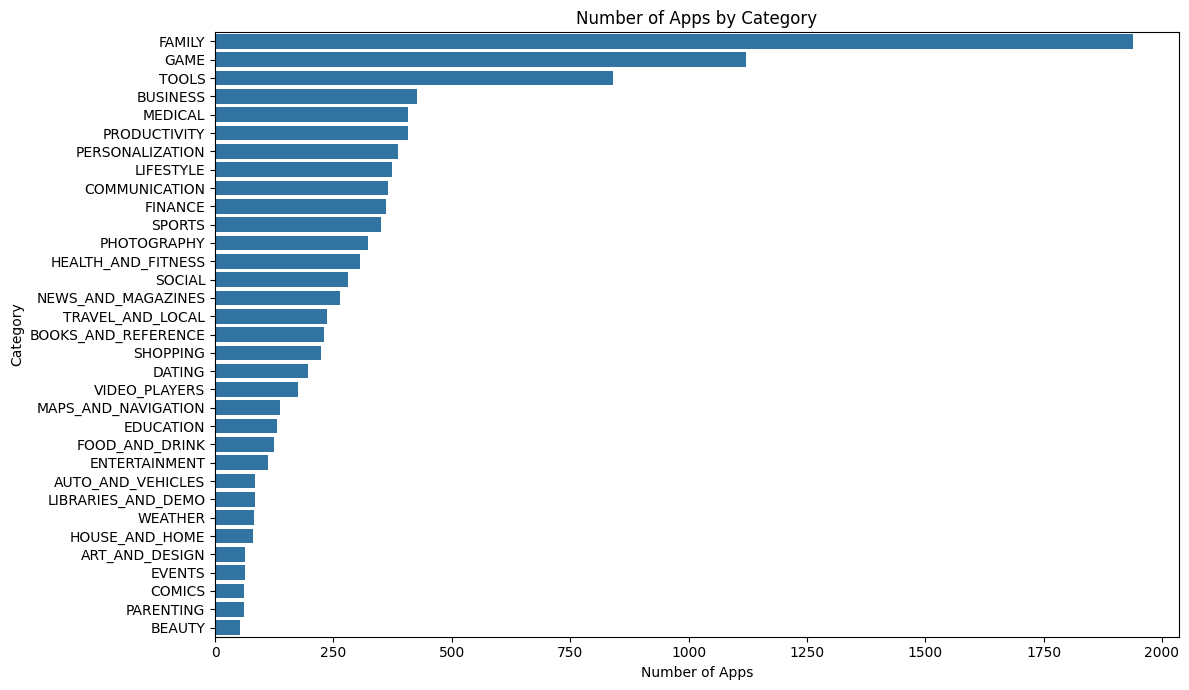

In [ ]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index
)

plt.title("Number of Apps by Category")
plt.xlabel("Number of Apps")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

### Observation

- The **FAMILY** category has the highest number of apps, indicating strong competition and market saturation.
- **GAME** and **TOOLS** are also highly populated categories.
- Categories such as **BEAUTY, PARENTING, COMICS, and EVENTS** have comparatively fewer apps.
- The distribution shows that app availability is highly concentrated in a few major categories, while several niche categories have much lower representation.

## 14. Ratings Analysis

App ratings are analyzed to understand the overall distribution of user ratings across the Google Play Store. This helps identify the typical rating range and overall user satisfaction.

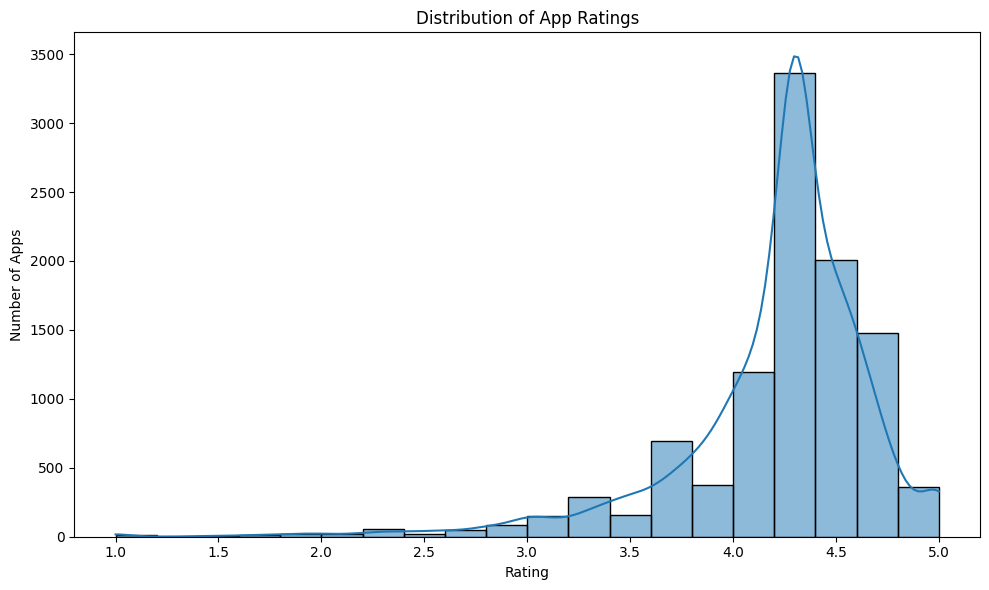

In [ ]:
plt.figure(figsize=(10, 6))

sns.histplot(apps['Rating'], bins=20, kde=True)

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.tight_layout()
plt.show()

### Observation

- Most apps have ratings between approximately **4.0 and 4.8**.
- The highest concentration of apps is around the **4.3–4.5 rating range**.
- Very few apps have ratings below **3.0**, indicating that low-rated apps are relatively uncommon in the dataset.
- Overall, the distribution suggests generally positive user ratings across the Google Play Store apps.

## 15. Average Rating by Category

The average rating of apps is calculated for each category to compare user satisfaction across different areas of the Google Play Store.

In [ ]:
avg_rating_category = (
    apps.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

print("Average Rating by Category:")
display(avg_rating_category)

Average Rating by Category:


,Rating
Category,
EVENTS,4.395313
EDUCATION,4.375385
ART_AND_DESIGN,4.373437
BOOKS_AND_REFERENCE,4.336681
PERSONALIZATION,4.326425
PARENTING,4.300000
BEAUTY,4.283019
GAME,4.282070
HEALTH_AND_FITNESS,4.266993


### Observation

- **EVENTS** has the highest average rating at approximately **4.40**, followed by **EDUCATION (4.38)** and **ART_AND_DESIGN (4.37)**.
- **DATING** has the lowest average rating at approximately **4.03**, followed by **MAPS_AND_NAVIGATION (4.08)** and **TOOLS (4.08)**.
- Most categories have an average rating above **4.0**, indicating generally positive user satisfaction.
- The difference between the highest and lowest category averages is relatively small, suggesting that ratings are fairly consistent across categories.

## 16. Average Rating by Category — Visualization

A horizontal bar chart is used to compare the average user rating across all app categories.

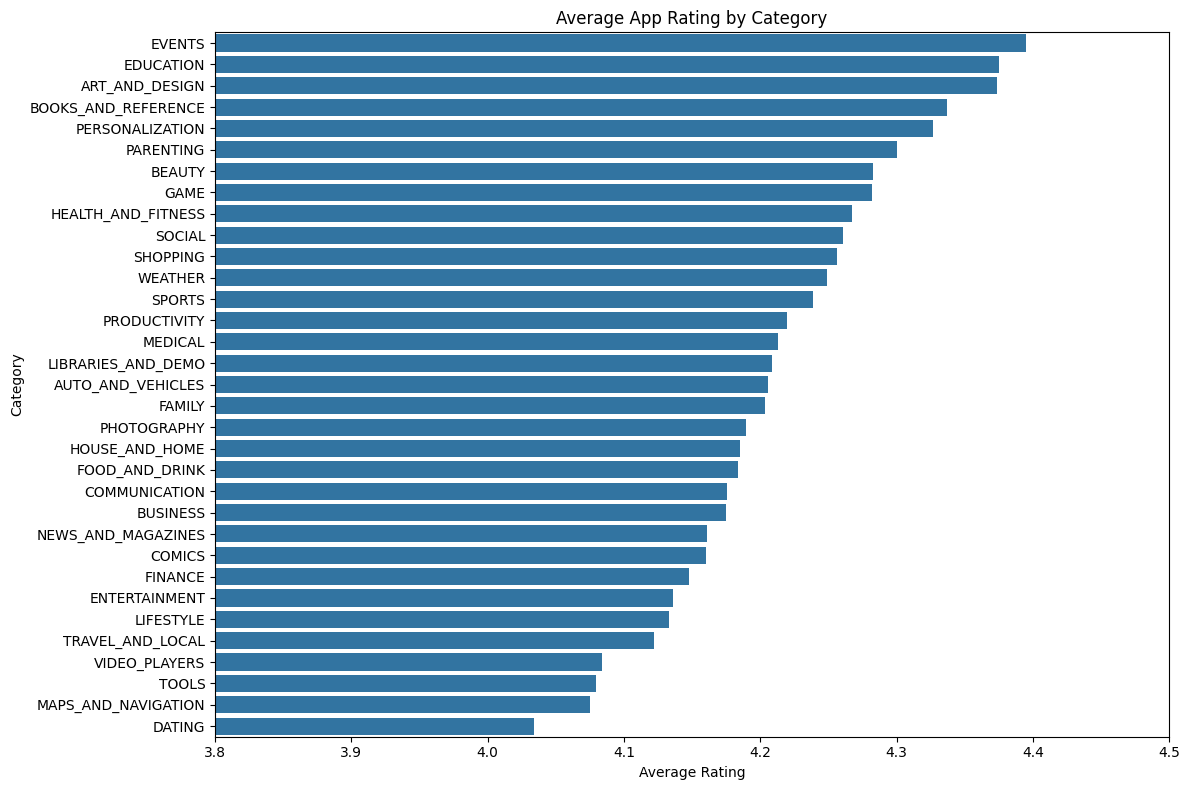

In [ ]:
plt.figure(figsize=(12, 8))

sns.barplot(
    x=avg_rating_category.values,
    y=avg_rating_category.index
)

plt.title("Average App Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")
plt.xlim(3.8, 4.5)

plt.tight_layout()
plt.show()

### Observation

- The **EVENTS** category has the highest average rating at approximately **4.40**.
- **EDUCATION** and **ART_AND_DESIGN** also have high average ratings of approximately **4.38** and **4.37**, respectively.
- **DATING** has the lowest average rating at approximately **4.03**.
- Despite differences between categories, the average ratings remain above **4.0**, indicating generally positive user satisfaction across the categories.

## 17. Size and Installs Analysis

The relationship between application size and the number of installs is analyzed to determine whether larger applications tend to receive more downloads. Apps with unavailable size information are excluded from this analysis.

In [ ]:
size_install_data = apps[['Size', 'Installs']].dropna()

print("Records available for Size vs Installs analysis:", len(size_install_data))

Records available for Size vs Installs analysis: 8821


### Observation

- A total of **8,821 apps** have valid values for both app size and number of installs.
- These records will be used to examine whether app size is associated with installation count.
- Apps with unavailable size information were excluded only for this analysis.

## 18. Relationship Between App Size and Installs

A scatter plot is used to examine the relationship between application size and the number of installs. This helps determine whether larger applications tend to receive more downloads.

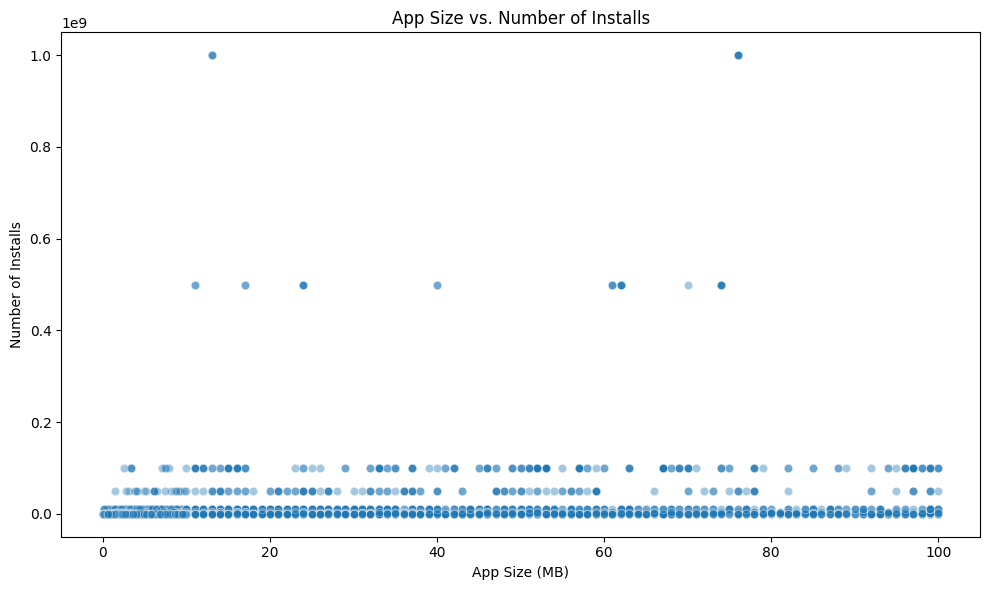

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=size_install_data,
    x='Size',
    y='Installs',
    alpha=0.4
)

plt.title("App Size vs. Number of Installs")
plt.xlabel("App Size (MB)")
plt.ylabel("Number of Installs")

plt.tight_layout()
plt.show()

### Observation

The scatter plot shows that app size does not have a strong visible relationship with the number of installs. Most apps are concentrated at relatively lower install counts across a wide range of sizes, while a few apps have extremely high installation counts.

This suggests that app size alone may not be a strong predictor of popularity. Other factors such as app category, ratings, reviews, and app quality may have a greater influence on the number of installs.

In [21]:
correlation = size_install_data['Size'].corr(size_install_data['Installs'])

print(f"Correlation between App Size and Installs: {correlation:.4f}")

Correlation between App Size and Installs: 0.1688


### Observation

The correlation between app size and number of installs is **0.1688**, indicating a weak positive relationship.

This means that larger apps tend to have slightly higher numbers of installs, but the relationship is not strong. Therefore, app size alone does not appear to be a major factor influencing an app's popularity or number of installs.

Other factors such as app category, ratings, reviews, pricing, and overall app quality may have a greater influence on downloads.

In [22]:
# Count free and paid apps
type_counts = apps['Type'].value_counts()

print("Free vs Paid Apps:")
print(type_counts)

Free vs Paid Apps:
Type
Free    9584
Paid     762
Name: count, dtype: int64


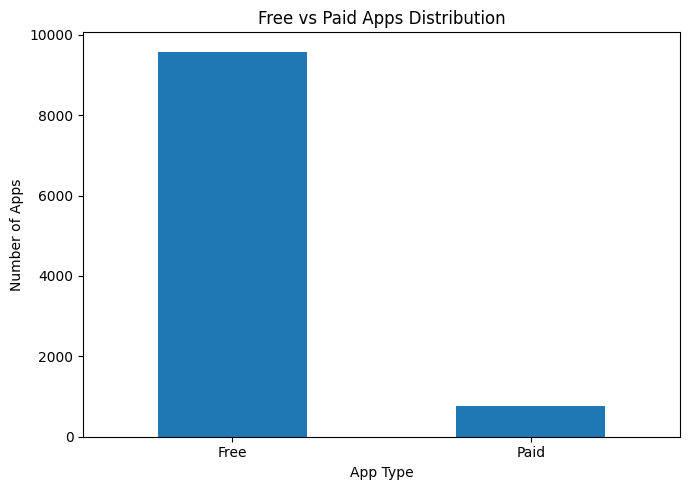

In [23]:
plt.figure(figsize=(7, 5))

type_counts.plot(kind='bar')

plt.title('Free vs Paid Apps Distribution')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The majority of apps on the Google Play Store are **free**, while only a smaller proportion are **paid**.

This indicates that the free-app model is much more common in the dataset. Developers may prefer offering apps for free to attract a larger user base and generate revenue through advertisements, in-app purchases, or other monetization strategies.

In [24]:
# Filter paid apps
paid_apps = apps[apps['Type'] == 'Paid'].copy()

print("Number of Paid Apps:", len(paid_apps))
print("\nPrice Statistics:")
print(paid_apps['Price'].describe())

Number of Paid Apps: 762

Price Statistics:
count    762.000000
mean      14.005945
std       58.516437
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


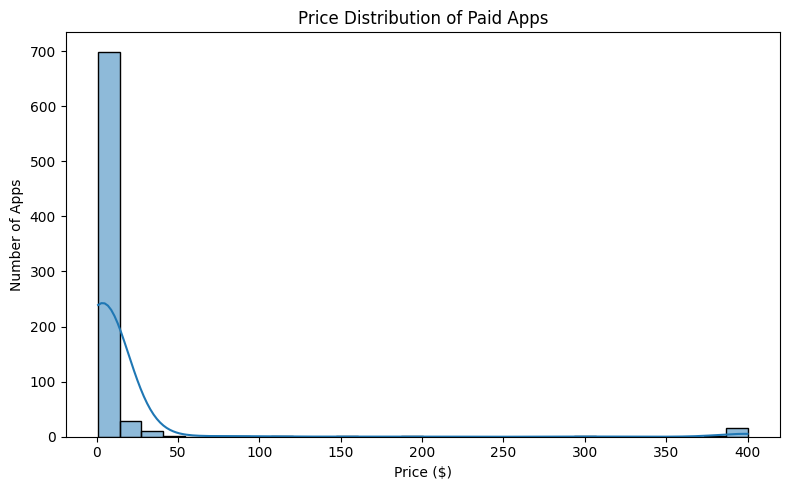

In [25]:
plt.figure(figsize=(8, 5))

sns.histplot(paid_apps['Price'], bins=30, kde=True)

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')

plt.tight_layout()
plt.show()

### Observation

The price distribution shows that most paid apps are concentrated in the lower price range, while only a small number of apps have relatively high prices.

This indicates that developers generally keep paid apps affordable, which may help attract more potential customers. The presence of a few high-priced apps also shows that pricing varies considerably across different applications.

In [26]:
# Estimate revenue for paid apps
paid_apps['Estimated_Revenue'] = paid_apps['Price'] * paid_apps['Installs']

# Revenue by category
revenue_by_category = (
    paid_apps.groupby('Category')['Estimated_Revenue']
    .sum()
    .sort_values(ascending=False)
)

print("Estimated Revenue by Category:")
print(revenue_by_category)

Estimated Revenue by Category:
Category
FAMILY                 1.857308e+08
LIFESTYLE              5.758394e+07
GAME                   4.098764e+07
FINANCE                2.572668e+07
PHOTOGRAPHY            8.942768e+06
MEDICAL                8.456536e+06
PERSONALIZATION        7.785458e+06
TOOLS                  5.464811e+06
SPORTS                 4.706212e+06
PRODUCTIVITY           4.313375e+06
COMMUNICATION          4.247364e+06
WEATHER                4.181380e+06
EDUCATION              2.403980e+06
HEALTH_AND_FITNESS     1.426069e+06
MAPS_AND_NAVIGATION    1.240789e+06
TRAVEL_AND_LOCAL       1.151504e+06
BUSINESS               1.050543e+06
ENTERTAINMENT          7.980000e+05
VIDEO_PLAYERS          3.352900e+05
FOOD_AND_DRINK         2.844000e+05
PARENTING              2.499590e+05
AUTO_AND_VEHICLES      1.001485e+05
BOOKS_AND_REFERENCE    9.022674e+04
DATING                 8.836150e+04
ART_AND_DESIGN         3.184000e+04
SHOPPING               3.014900e+04
NEWS_AND_MAGAZINES     6

### Observation

- The **FAMILY** category has the highest estimated revenue at approximately **$185.73 million**.
- **LIFESTYLE**, **GAME**, and **FINANCE** are the next highest revenue-generating categories.
- Several categories such as **EVENTS, LIBRARIES_AND_DEMO, SOCIAL, and NEWS_AND_MAGAZINES** have comparatively low estimated revenue from paid apps.
- The results indicate that the number of paid apps alone does not determine revenue; pricing and estimated installations also play important roles.
- These revenue values are estimates based on the assumption that every installation of a paid app represents a purchase at the listed price. Actual revenue may differ because of discounts, refunds, taxes, platform fees, and other monetization factors.

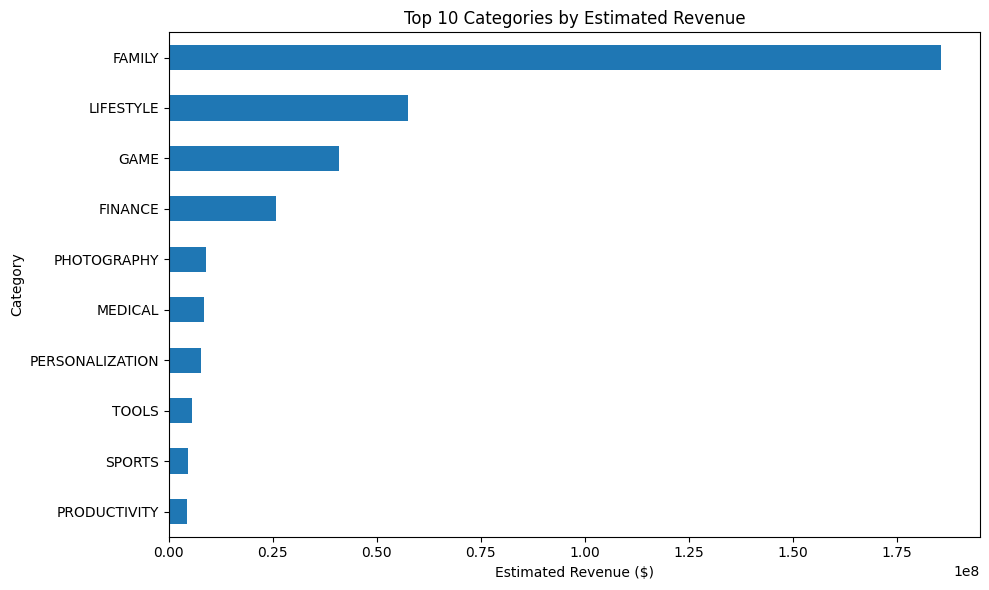

In [27]:
plt.figure(figsize=(10, 6))

revenue_by_category.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 Categories by Estimated Revenue')
plt.xlabel('Estimated Revenue ($)')
plt.ylabel('Category')

plt.tight_layout()
plt.show()

### Observation

The **FAMILY** category has the highest estimated revenue by a very large margin, followed by **LIFESTYLE**, **GAME**, and **FINANCE**.

Among the top 10 categories, FAMILY contributes substantially more estimated revenue than the other categories. Photography, Medical, Personalization, Tools, Sports, and Productivity generate comparatively lower estimated revenue.

This suggests that categories with a combination of paid apps, higher prices, and larger estimated install counts can generate significantly higher potential revenue.

## 20. Sentiment Analysis of User Reviews

User reviews provide valuable insights into how users perceive applications on the Google Play Store. In this section, the sentiment of user reviews is analyzed by examining the distribution of **Positive, Negative, and Neutral** reviews.

The analysis helps identify the overall user perception of applications and provides insights that can support developers in understanding customer satisfaction and areas for improvement.

In [28]:
# Overall sentiment distribution
sentiment_counts = reviews['Sentiment'].value_counts()

print("Overall Sentiment Distribution:")
print(sentiment_counts)

Overall Sentiment Distribution:
Sentiment
Positive    19015
Negative     6321
Neutral      4356
Name: count, dtype: int64


### Observation

The sentiment analysis shows that **Positive reviews are the most common**, with **19,015 reviews**, followed by **Negative reviews with 6,321 reviews** and **Neutral reviews with 4,356 reviews**.

This indicates that the overall user sentiment in the dataset is predominantly positive. However, the presence of more than 6,000 negative reviews highlights that there are still areas where app developers can improve user experience and satisfaction.

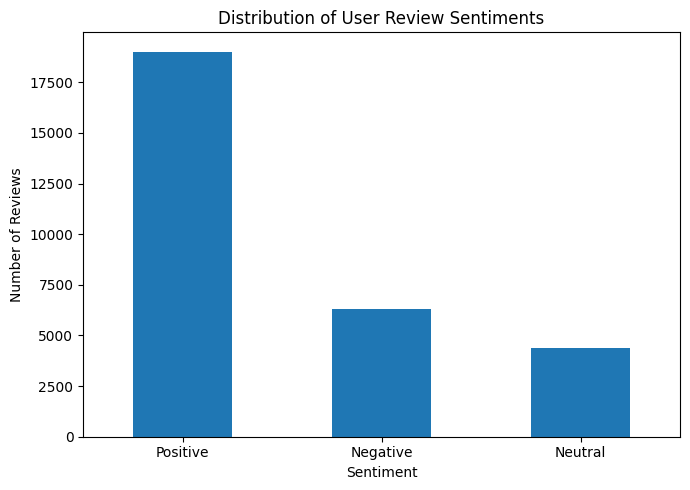

In [29]:
plt.figure(figsize=(7, 5))

sentiment_counts.plot(kind='bar')

plt.title('Distribution of User Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The sentiment distribution confirms that **Positive reviews are the most common**, with 19,015 reviews. Negative reviews account for 6,321 reviews, while Neutral reviews account for 4,356 reviews.

The visualization shows that the overall user feedback in the dataset is predominantly positive. However, the considerable number of negative reviews indicates that some applications still have user experience issues that developers should address.

In [30]:
# Merge app categories with user review sentiment
reviews_with_category = reviews.merge(
    apps[['App', 'Category']],
    on='App',
    how='left'
)

print("Merged Dataset Shape:", reviews_with_category.shape)
print("\nMissing Categories:")
print(reviews_with_category['Category'].isna().sum())

Merged Dataset Shape: (41856, 6)

Missing Categories:
1442


### Data Preparation for Category-wise Sentiment Analysis

The user reviews dataset was merged with the apps dataset using the `App` column to obtain the corresponding app category.

The merged dataset contains **41,856 records**. A total of **1,442 records** do not have a matching category and will therefore be excluded from category-wise sentiment analysis. This ensures that the following analysis is based only on reviews with a valid app category.

In [31]:
# Remove reviews without a valid app category
reviews_with_category = reviews_with_category.dropna(subset=['Category'])

print("Shape after removing missing categories:", reviews_with_category.shape)

Shape after removing missing categories: (40414, 6)


In [33]:
category_sentiment = pd.crosstab(
    reviews_with_category['Category'],
    reviews_with_category['Sentiment']
)

print("Sentiment Distribution by Category:")
print(category_sentiment)

Sentiment Distribution by Category:
Sentiment            Negative  Neutral  Positive
Category                                        
ART_AND_DESIGN             54       60       240
AUTO_AND_VEHICLES          17       36       230
BEAUTY                     60       81       176
BOOKS_AND_REFERENCE       108      123       480
BUSINESS                  144      201       458
COMICS                      2        6        72
COMMUNICATION             254      211       823
DATING                    322      268       897
EDUCATION                  87       90       560
ENTERTAINMENT             218      121       528
EVENTS                     16       17       123
FAMILY                    984      315      2251
FINANCE                   350      219      1012
FOOD_AND_DRINK             83       78       501
GAME                     3485      414      5394
HEALTH_AND_FITNESS        215      217      1456
HOUSE_AND_HOME             85      111       308
LIBRARIES_AND_DEMO         51    

### Observation

The category-wise sentiment distribution shows that positive reviews are generally higher than negative and neutral reviews across most app categories.

The **GAME** category has the highest number of positive reviews (5,394) as well as the highest number of negative reviews (3,485), mainly because it contains a large number of reviews in the dataset.

Other categories such as **FAMILY, HEALTH_AND_FITNESS, FINANCE, PHOTOGRAPHY, and PRODUCTIVITY** also have substantial numbers of positive reviews.

Since the number of reviews varies considerably between categories, sentiment proportions will be calculated next to provide a fairer comparison between categories.

In [34]:
category_sentiment_pct = category_sentiment.div(
    category_sentiment.sum(axis=1),
    axis=0
) * 100

print("Sentiment Percentage by Category:")
print(category_sentiment_pct.round(2))

Sentiment Percentage by Category:
Sentiment            Negative  Neutral  Positive
Category                                        
ART_AND_DESIGN          15.25    16.95     67.80
AUTO_AND_VEHICLES        6.01    12.72     81.27
BEAUTY                  18.93    25.55     55.52
BOOKS_AND_REFERENCE     15.19    17.30     67.51
BUSINESS                17.93    25.03     57.04
COMICS                   2.50     7.50     90.00
COMMUNICATION           19.72    16.38     63.90
DATING                  21.65    18.02     60.32
EDUCATION               11.80    12.21     75.98
ENTERTAINMENT           25.14    13.96     60.90
EVENTS                  10.26    10.90     78.85
FAMILY                  27.72     8.87     63.41
FINANCE                 22.14    13.85     64.01
FOOD_AND_DRINK          12.54    11.78     75.68
GAME                    37.50     4.45     58.04
HEALTH_AND_FITNESS      11.39    11.49     77.12
HOUSE_AND_HOME          16.87    22.02     61.11
LIBRARIES_AND_DEMO      15.36    13

### Observation

The sentiment percentages show that **Comics** has the highest proportion of positive reviews at **90.00%**, followed by **Auto & Vehicles (81.27%)**, **Events (78.85%)**, and **Health & Fitness (77.12%)**.

On the other hand, **Games** has the highest proportion of negative reviews at **37.50%**, followed by **Social (31.59%)** and **Family (27.72%)**.

Most categories have a higher proportion of positive reviews than negative reviews, indicating generally favorable user sentiment. However, categories with relatively high negative sentiment, particularly Games and Social, may have greater opportunities for improving user experience.

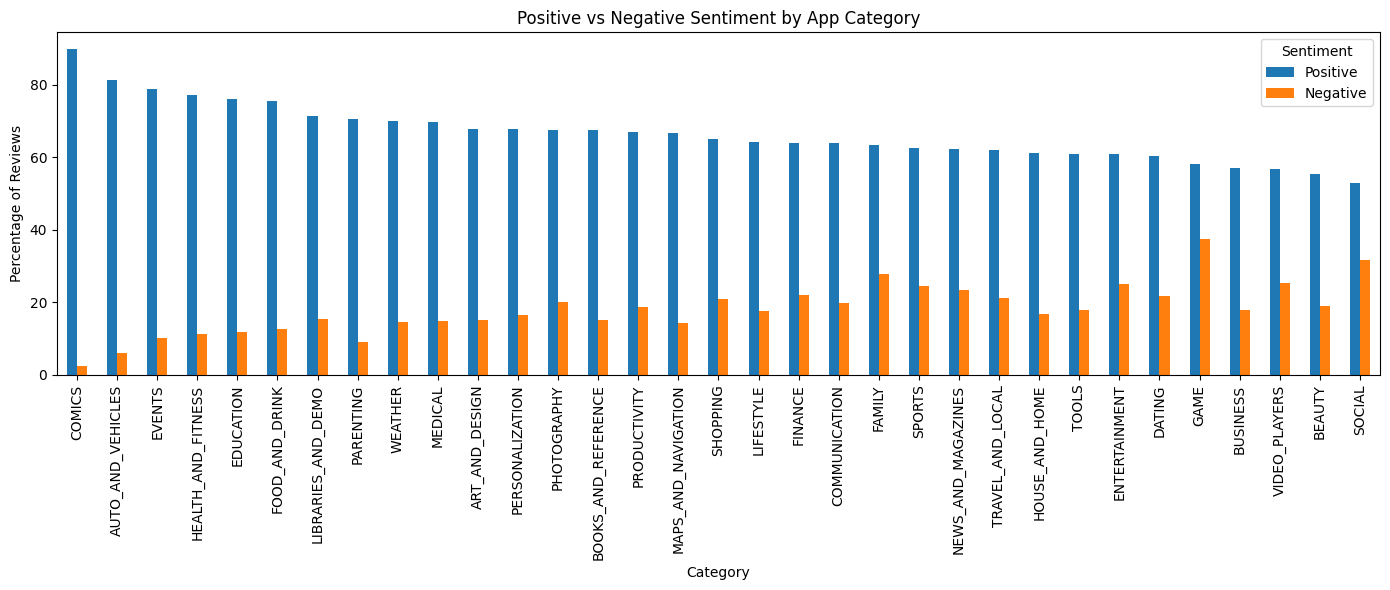

In [35]:
# Visualize positive and negative sentiment percentages by category

category_sentiment_pct[['Positive', 'Negative']].sort_values(
    'Positive',
    ascending=False
).plot(
    kind='bar',
    figsize=(14, 6)
)

plt.title('Positive vs Negative Sentiment by App Category')
plt.xlabel('Category')
plt.ylabel('Percentage of Reviews')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Observation

The comparison shows that **Comics** has the highest proportion of positive reviews at **90.00%**, while **Games** has the highest proportion of negative reviews at **37.50%**.

Categories such as **Auto & Vehicles, Events, Health & Fitness, Education, and Food & Drink** also show relatively high positive sentiment.

In contrast, **Games, Social, Family, Video Players, and Entertainment** have comparatively higher negative sentiment proportions. These categories may provide opportunities for developers to investigate user complaints and improve the overall user experience.

## Interactive Visualization – Sentiment by App Category

To provide an interactive view of user sentiment across app categories, Plotly is used to visualize the percentage of positive, negative, and neutral reviews. The interactive chart allows users to compare sentiment patterns across different categories.

In [38]:
# Find the dataframe containing both Category and Sentiment
[name for name, obj in globals().items()
 if isinstance(obj, pd.DataFrame)
 and 'Category' in obj.columns
 and 'Sentiment' in obj.columns]

['reviews_with_category']

In [39]:
# Calculate sentiment percentage by app category

sentiment_percentage = pd.crosstab(
    reviews_with_category['Category'],
    reviews_with_category['Sentiment'],
    normalize='index'
) * 100

sentiment_percentage

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,15.254237,16.949153,67.796610
AUTO_AND_VEHICLES,6.007067,12.720848,81.272085
BEAUTY,18.927445,25.552050,55.520505
BOOKS_AND_REFERENCE,15.189873,17.299578,67.510549
BUSINESS,17.932752,25.031133,57.036115
COMICS,2.500000,7.500000,90.000000
COMMUNICATION,19.720497,16.381988,63.897516
DATING,21.654338,18.022865,60.322798
EDUCATION,11.804613,12.211669,75.983718


## 21. Interactive Sentiment Visualization

An interactive visualization is created using Plotly to compare positive, negative, and neutral sentiment percentages across Google Play Store app categories. The interactive chart allows users to explore sentiment patterns for individual categories.

In [40]:
# Prepare data for Plotly
sentiment_percentage_plot = sentiment_percentage.reset_index().melt(
    id_vars='Category',
    value_vars=['Positive', 'Negative', 'Neutral'],
    var_name='Sentiment',
    value_name='Percentage'
)

# Create interactive Plotly chart
fig = px.bar(
    sentiment_percentage_plot,
    x='Category',
    y='Percentage',
    color='Sentiment',
    barmode='group',
    title='Interactive Sentiment Analysis by App Category',
    labels={
        'Percentage': 'Percentage of Reviews (%)',
        'Category': 'App Category'
    },
    hover_data={'Percentage': ':.2f'}
)

fig.update_layout(
    xaxis_tickangle=-45,
    height=650
)

fig.show()

### Observation

The interactive visualization shows that positive reviews form the largest share of user feedback across most app categories. Comics has the highest proportion of positive reviews at 90%, while Games has the highest proportion of negative reviews at approximately 37.5%. The chart also shows that neutral reviews generally form a smaller proportion compared with positive reviews, although some categories such as Beauty, Business, and House & Home have relatively higher neutral sentiment.

## 22. Conclusion – Key Insights for App Developers

1. **Focus on user satisfaction:** Positive sentiment dominates most app categories, indicating that delivering a reliable and user-friendly experience is important for gaining favorable reviews.

2. **Pay attention to category-specific complaints:** Games and Social apps show relatively high proportions of negative reviews. Developers entering these categories should carefully identify common user complaints and address them during product development.

3. **Choose the category strategically:** The analysis shows that the Family category has the largest number of apps and the highest estimated revenue, while categories such as Events and Education have some of the highest average ratings. Developers can use category competition, ratings, sentiment, and revenue patterns together when selecting a market.